# Big Data Analytics – Final Project
## Titanic Survival Prediction with PySpark & MLlib

### Project Structure
1. Environment Setup
2. Extract – Load raw data into Spark
3. Transform – Clean, impute, engineer features
4. Load – Save clean dataset
5. Exploratory Data Analysis
6. Predictive Model (MLlib)
7. Visualizations

In [ ]:
# Install packages
!pip install pyspark pandas matplotlib seaborn plotly -q

In [ ]:
# Core Spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType

# MLlib
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, Imputer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Visualization
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [ ]:
# Initialize SparkSession
spark = SparkSession.builder \
    .appName('BigData_Titanic_FinalProject') \
    .config('spark.driver.memory', '2g') \
    .config('spark.sql.shuffle.partitions', '4') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'Spark version: {spark.version}')
print(f'App name    : {spark.sparkContext.appName}')

Spark version: 4.0.2
App name    : BigData_Titanic_FinalProject


### Stage 1 – EXTRACT
Load the raw Titanic CSV into a Spark DataFrame with an explicit schema.

**Dataset source:** [Kaggle Titanic](https://www.kaggle.com/c/titanic/data)  
Download `train.csv` and place it in the same folder as this notebook, or load directly from URL using the cell below.

In [ ]:
# Download dataset automatically
# We use the seaborn built-in Titanic dataset as a fallback (same data)

import os

CSV_PATH = 'titanic.csv'

if not os.path.exists(CSV_PATH):
    print('Downloading Titanic dataset via seaborn...')
    titanic_pd = sns.load_dataset('titanic')
    # Rename columns to match Kaggle format
    titanic_pd = titanic_pd.rename(columns={
        'survived': 'Survived',
        'pclass': 'Pclass',
        'sex': 'Sex',
        'age': 'Age',
        'sibsp': 'SibSp',
        'parch': 'Parch',
        'fare': 'Fare',
        'embarked': 'Embarked'
    })
    titanic_pd['Name'] = 'Passenger_' + titanic_pd.index.astype(str)
    titanic_pd['Ticket'] = 'T' + titanic_pd.index.astype(str)
    titanic_pd['Cabin'] = None
    titanic_pd['PassengerId'] = titanic_pd.index + 1
    titanic_pd = titanic_pd[['PassengerId','Survived','Pclass','Name','Sex','Age',
                              'SibSp','Parch','Ticket','Fare','Cabin','Embarked']]
    titanic_pd.to_csv(CSV_PATH, index=False)
    print(f'Saved {len(titanic_pd)} rows to {CSV_PATH}')
else:
    print(f'Found existing {CSV_PATH}')

Found existing titanic.csv


In [ ]:
# Define explicit schema
# Explicit schemas prevent type inference errors and improve performance

titanic_schema = StructType([
    StructField('PassengerId', IntegerType(), nullable=True),
    StructField('Survived',    IntegerType(), nullable=True),
    StructField('Pclass',      IntegerType(), nullable=True),
    StructField('Name',        StringType(),  nullable=True),
    StructField('Sex',         StringType(),  nullable=True),
    StructField('Age',         DoubleType(),  nullable=True),
    StructField('SibSp',       IntegerType(), nullable=True),
    StructField('Parch',       IntegerType(), nullable=True),
    StructField('Ticket',      StringType(),  nullable=True),
    StructField('Fare',        DoubleType(),  nullable=True),
    StructField('Cabin',       StringType(),  nullable=True),
    StructField('Embarked',    StringType(),  nullable=True),
])

print('Schema defined')

Schema defined


In [ ]:
# EXTRACT: Load CSV into Spark DataFrame
raw_df = spark.read \
    .option('header', 'true') \
    .option('nullValue', '') \
    .schema(titanic_schema) \
    .csv(CSV_PATH)

print(f'Extracted {raw_df.count()} rows, {len(raw_df.columns)} columns')
print('\nSchema:')
raw_df.printSchema()

Extracted 891 rows, 12 columns

Schema:
root
 |-- PassengerId: integer (nullable = true)
 |-- Survived: integer (nullable = true)
 |-- Pclass: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Sex: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- SibSp: integer (nullable = true)
 |-- Parch: integer (nullable = true)
 |-- Ticket: string (nullable = true)
 |-- Fare: double (nullable = true)
 |-- Cabin: string (nullable = true)
 |-- Embarked: string (nullable = true)



In [ ]:
# Preview first 5 rows
raw_df.show(5, truncate=False)

+-----------+--------+------+-----------+------+----+-----+-----+------+-------+-----+--------+
|PassengerId|Survived|Pclass|Name       |Sex   |Age |SibSp|Parch|Ticket|Fare   |Cabin|Embarked|
+-----------+--------+------+-----------+------+----+-----+-----+------+-------+-----+--------+
|1          |0       |3     |Passenger_0|male  |22.0|1    |0    |T0    |7.25   |NULL |S       |
|2          |1       |1     |Passenger_1|female|38.0|1    |0    |T1    |71.2833|NULL |C       |
|3          |1       |3     |Passenger_2|female|26.0|0    |0    |T2    |7.925  |NULL |S       |
|4          |1       |1     |Passenger_3|female|35.0|1    |0    |T3    |53.1   |NULL |S       |
|5          |0       |3     |Passenger_4|male  |35.0|0    |0    |T4    |8.05   |NULL |S       |
+-----------+--------+------+-----------+------+----+-----+-----+------+-------+-----+--------+
only showing top 5 rows


---
### Stage 2 – TRANSFORM
Apply advanced data cleaning and feature engineering:
1. Quality check – Count nulls, duplicates, and run `describe()`
2. Missing values – Impute Age (median), fill Embarked (mode), drop Cabin
3. Duplicates – Detect and remove
4. Outliers – IQR-based detection on Fare and Age
5. Feature engineering – FamilySize, IsAlone, Title
6. Encoding – Index categorical columns for MLlib

In [ ]:
# 2.1  DATA QUALITY ASSESSMENT

print('=' * 60)
print('  DATA QUALITY REPORT')
print('=' * 60)

# Summary statistics
print('\nDescriptive Statistics (describe)')
raw_df.describe(['Age', 'Fare', 'SibSp', 'Parch', 'Pclass']).show()

# Null counts per column
print('\nNull Counts per Column')
null_counts = raw_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in raw_df.columns
])
null_counts.show()

#  Null percentage
total = raw_df.count()
print(f'\nNull Percentage (total rows = {total})')
for col_name in raw_df.columns:
    n = raw_df.filter(F.col(col_name).isNull()).count()
    if n > 0:
        print(f'   {col_name:<15}: {n} nulls ({n/total*100:.1f}%)')

# Duplicates
dupes = raw_df.count() - raw_df.dropDuplicates().count()
print(f'\n── Duplicate rows: {dupes}')

  DATA QUALITY REPORT

Descriptive Statistics (describe)
+-------+------------------+-----------------+------------------+-------------------+------------------+
|summary|               Age|             Fare|             SibSp|              Parch|            Pclass|
+-------+------------------+-----------------+------------------+-------------------+------------------+
|  count|               714|              891|               891|                891|               891|
|   mean| 29.69911764705882| 32.2042079685746|0.5230078563411896|0.38159371492704824| 2.308641975308642|
| stddev|14.526497332334035|49.69342859718089|1.1027434322934315| 0.8060572211299488|0.8360712409770491|
|    min|              0.42|              0.0|                 0|                  0|                 1|
|    max|              80.0|         512.3292|                 8|                  6|                 3|
+-------+------------------+-----------------+------------------+-------------------+------------------

In [ ]:
# 2.2  OUTLIER DETECTION (IQR method)
# Outliers are defined as values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR

def iqr_outliers(df, col_name):
    """Return outlier count and bounds for a numeric column."""
    quantiles = df.approxQuantile(col_name, [0.25, 0.75], 0.01)
    q1, q3 = quantiles[0], quantiles[1]
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = df.filter((F.col(col_name) < lower) | (F.col(col_name) > upper)).count()
    return q1, q3, lower, upper, n_out

print('── Outlier Report (IQR Method) ─────────────────────────────')
print(f'{"Column":<10} {"Q1":>8} {"Q3":>8} {"Lower":>10} {"Upper":>10} {"Outliers":>10}')
print('-' * 60)

outlier_cols = ['Age', 'Fare']
outlier_bounds = {}
for col in outlier_cols:
    q1, q3, lo, hi, n = iqr_outliers(raw_df.dropna(subset=[col]), col)
    outlier_bounds[col] = (lo, hi)
    print(f'{col:<10} {q1:>8.2f} {q3:>8.2f} {lo:>10.2f} {hi:>10.2f} {n:>10}')

# Strategy: Cap outliers (Winsorization) instead of dropping rows
print('\n➡ Strategy: Cap outliers (Winsorization) to preserve data')

── Outlier Report (IQR Method) ─────────────────────────────
Column           Q1       Q3      Lower      Upper   Outliers
------------------------------------------------------------
Age           20.00    38.00      -7.00      65.00          8
Fare           7.90    30.50     -26.01      64.41        118

➡ Strategy: Cap outliers (Winsorization) to preserve data


In [ ]:
# 2.3  APPLY TRANSFORMATIONS

# Remove duplicates
df = raw_df.dropDuplicates()
print(f'After dedup: {df.count()} rows')

# Drop Cabin (>70% missing – not recoverable)
df = df.drop('Cabin')

#  Fill missing Embarked with mode
embarked_mode = df.groupBy('Embarked').count().orderBy(F.desc('count')).first()['Embarked']
df = df.fillna({'Embarked': embarked_mode})
print(f'Embarked mode fill: "{embarked_mode}"')

# Impute Age with median using Spark Imputer
age_median = df.approxQuantile('Age', [0.5], 0.01)[0]
df = df.fillna({'Age': age_median})
print(f'Age median imputation: {age_median:.1f}')

# Winsorize Fare outliers
fare_lo, fare_hi = outlier_bounds['Fare']
df = df.withColumn('Fare', F.when(F.col('Fare') > fare_hi, fare_hi)
                             .when(F.col('Fare') < fare_lo, fare_lo)
                             .otherwise(F.col('Fare')))

# Drop rows still missing target or critical fields
df = df.dropna(subset=['Survived'])
print(f'After full cleaning: {df.count()} rows')

After dedup: 891 rows
Embarked mode fill: "S"
Age median imputation: 28.0
After full cleaning: 891 rows


In [ ]:
# 2.4  FEATURE ENGINEERING

# FamilySize: total family members on board
df = df.withColumn('FamilySize', F.col('SibSp') + F.col('Parch') + 1)

#  IsAlone: binary flag for solo travellers
df = df.withColumn('IsAlone', F.when(F.col('FamilySize') == 1, 1).otherwise(0))

# AgeGroup: bucket Age into categorical bins
df = df.withColumn('AgeGroup',
    F.when(F.col('Age') < 12, 'Child')
     .when(F.col('Age') < 18, 'Teenager')
     .when(F.col('Age') < 60, 'Adult')
     .otherwise('Senior'))

# FareGroup: quartile-based fare category
df = df.withColumn('FareGroup',
    F.when(F.col('Fare') <= 7.9, 'Low')
     .when(F.col('Fare') <= 14.4, 'Medium')
     .when(F.col('Fare') <= 31.0, 'High')
     .otherwise('Very High'))

print('Feature engineering complete. New columns:')
df.select('FamilySize', 'IsAlone', 'AgeGroup', 'FareGroup').show(5)

Feature engineering complete. New columns:
+----------+-------+--------+---------+
|FamilySize|IsAlone|AgeGroup|FareGroup|
+----------+-------+--------+---------+
|         1|      1|   Adult|   Medium|
|         1|      1|   Adult|   Medium|
|         7|      0|   Adult|Very High|
|         1|      1|   Adult|   Medium|
|         2|      0|   Adult|     High|
+----------+-------+--------+---------+
only showing top 5 rows


In [ ]:
# 2.5  QUALITY VALIDATION – POST TRANSFORM

print('Post-Transform Quality Validation')
remaining_nulls = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
])
remaining_nulls.show()

print('Describe after cleaning')
df.describe(['Age', 'Fare', 'FamilySize']).show()

print(f'Clean dataset: {df.count()} rows × {len(df.columns)} columns')

Post-Transform Quality Validation
+-----------+--------+------+----+---+---+-----+-----+------+----+--------+----------+-------+--------+---------+
|PassengerId|Survived|Pclass|Name|Sex|Age|SibSp|Parch|Ticket|Fare|Embarked|FamilySize|IsAlone|AgeGroup|FareGroup|
+-----------+--------+------+----+---+---+-----+-----+------+----+--------+----------+-------+--------+---------+
|          0|       0|     0|   0|  0|  0|    0|    0|     0|   0|       0|         0|      0|       0|        0|
+-----------+--------+------+----+---+---+-----+-----+------+----+--------+----------+-------+--------+---------+

Describe after cleaning
+-------+-----------------+------------------+-----------------+
|summary|              Age|              Fare|       FamilySize|
+-------+-----------------+------------------+-----------------+
|  count|              891|               891|              891|
|   mean|29.36158249158249|23.885593378226655|1.904601571268238|
| stddev| 13.0196965509732|20.155530725240205|

---
### Stage 3 – LOAD
Persist the cleaned data in **Parquet** format — the industry standard for Spark because it is columnar, compressed, and schema-preserving.

In [ ]:
# LOAD: Persist clean data as Parquet

PARQUET_PATH = 'titanic_clean.parquet'

df.write.mode('overwrite').parquet(PARQUET_PATH)
print(f'Clean data saved to: {PARQUET_PATH}')

# Reload to confirm roundtrip integrity
df_loaded = spark.read.parquet(PARQUET_PATH)
print(f'Reload check: {df_loaded.count()} rows, {len(df_loaded.columns)} columns')

# Register as temp view for SQL queries in EDA
df_loaded.createOrReplaceTempView('titanic')
print('Spark SQL temp view "titanic" registered')

Clean data saved to: titanic_clean.parquet
Reload check: 891 rows, 15 columns
Spark SQL temp view "titanic" registered


### Stage 4 – EXPLORATORY DATA ANALYSIS (EDA)
Perform descriptive statistics, correlations, groupings, and frequency analysis using Spark DataFrames and Spark SQL.

In [ ]:
# Survival rate overall and by class

print('Overall Survival Rate ')
df_loaded.groupBy('Survived').count() \
    .withColumn('Pct', F.round(F.col('count') / df_loaded.count() * 100, 1)) \
    .orderBy('Survived').show()

print('Survival Rate by Passenger Class')
df_loaded.groupBy('Pclass', 'Survived') \
    .agg(F.count('*').alias('Count')) \
    .orderBy('Pclass', 'Survived').show()

print('Survival Rate by Sex')
df_loaded.groupBy('Sex') \
    .agg(F.round(F.mean('Survived') * 100, 1).alias('SurvivalRate_%'),
         F.count('*').alias('Count')) \
    .orderBy('Sex').show()

Overall Survival Rate 
+--------+-----+----+
|Survived|count| Pct|
+--------+-----+----+
|       0|  549|61.6|
|       1|  342|38.4|
+--------+-----+----+

Survival Rate by Passenger Class
+------+--------+-----+
|Pclass|Survived|Count|
+------+--------+-----+
|     1|       0|   80|
|     1|       1|  136|
|     2|       0|   97|
|     2|       1|   87|
|     3|       0|  372|
|     3|       1|  119|
+------+--------+-----+

Survival Rate by Sex
+------+--------------+-----+
|   Sex|SurvivalRate_%|Count|
+------+--------------+-----+
|female|          74.2|  314|
|  male|          18.9|  577|
+------+--------------+-----+



In [ ]:
# Descriptive stats by Pclass and correlation analysis

print('── Avg Age, Fare, and Survival by Pclass ───────────────────')
df_loaded.groupBy('Pclass').agg(
    F.round(F.mean('Age'), 1).alias('AvgAge'),
    F.round(F.mean('Fare'), 2).alias('AvgFare'),
    F.round(F.mean('Survived') * 100, 1).alias('SurvivalRate_%'),
    F.count('*').alias('Count')
).orderBy('Pclass').show()

print('Correlation Matrix (numeric columns)')
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
corr_data = {}
for c1 in num_cols:
    corr_data[c1] = {}
    for c2 in num_cols:
        corr_data[c1][c2] = round(df_loaded.stat.corr(c1, c2), 3)

corr_pd = pd.DataFrame(corr_data)
print(corr_pd.to_string())

── Avg Age, Fare, and Survival by Pclass ───────────────────
+------+------+-------+--------------+-----+
|Pclass|AvgAge|AvgFare|SurvivalRate_%|Count|
+------+------+-------+--------------+-----+
|     1|  36.8|  50.22|          63.0|  216|
|     2|  29.8|  20.41|          47.3|  184|
|     3|  25.9|   13.6|          24.2|  491|
+------+------+-------+--------------+-----+

Correlation Matrix (numeric columns)
            Survived  Pclass    Age  SibSp  Parch   Fare  FamilySize  IsAlone
Survived       1.000  -0.338 -0.065 -0.035  0.082  0.318       0.017   -0.203
Pclass        -0.338   1.000 -0.340  0.083  0.018 -0.716       0.066    0.135
Age           -0.065  -0.340  1.000 -0.233 -0.172  0.144      -0.246    0.172
SibSp         -0.035   0.083 -0.233  1.000  0.415  0.333       0.891   -0.584
Parch          0.082   0.018 -0.172  0.415  1.000  0.295       0.783   -0.583
Fare           0.318  -0.716  0.144  0.333  0.295  1.000       0.375   -0.456
FamilySize     0.017   0.066 -0.246  0.8

In [ ]:

# Frequency tables for categorical variables

print('Embarked Frequency')
df_loaded.groupBy('Embarked').count().orderBy(F.desc('count')).show()

print('AgeGroup Frequency')
df_loaded.groupBy('AgeGroup').count().orderBy(F.desc('count')).show()

print('Family Size Distribution')
df_loaded.groupBy('FamilySize') \
    .agg(F.count('*').alias('Count'),
         F.round(F.mean('Survived') * 100, 1).alias('SurvivalRate_%')) \
    .orderBy('FamilySize').show()

print('SQL Query: Survival pivot by Sex × Pclass')
spark.sql("""
    SELECT Sex,
           ROUND(AVG(CASE WHEN Pclass=1 THEN Survived END)*100,1) AS Class1_Surv,
           ROUND(AVG(CASE WHEN Pclass=2 THEN Survived END)*100,1) AS Class2_Surv,
           ROUND(AVG(CASE WHEN Pclass=3 THEN Survived END)*100,1) AS Class3_Surv
    FROM titanic
    GROUP BY Sex
""").show()

Embarked Frequency
+--------+-----+
|Embarked|count|
+--------+-----+
|       S|  646|
|       C|  168|
|       Q|   77|
+--------+-----+

AgeGroup Frequency
+--------+-----+
|AgeGroup|count|
+--------+-----+
|   Adult|  752|
|   Child|   68|
|Teenager|   45|
|  Senior|   26|
+--------+-----+

Family Size Distribution
+----------+-----+--------------+
|FamilySize|Count|SurvivalRate_%|
+----------+-----+--------------+
|         1|  537|          30.4|
|         2|  161|          55.3|
|         3|  102|          57.8|
|         4|   29|          72.4|
|         5|   15|          20.0|
|         6|   22|          13.6|
|         7|   12|          33.3|
|         8|    6|           0.0|
|        11|    7|           0.0|
+----------+-----+--------------+

SQL Query: Survival pivot by Sex × Pclass
+------+-----------+-----------+-----------+
|   Sex|Class1_Surv|Class2_Surv|Class3_Surv|
+------+-----------+-----------+-----------+
|  male|       36.9|       15.7|       13.5|
|female|       

### Stage 5 – PREDICTIVE MODEL (MLlib)

Algorithm Choice: Random Forest Classifier

Justification:
- Binary classification task (Survived = 0 or 1)
- Mix of numeric and categorical features
- Random Forest is robust to outliers, handles non-linearity, provides feature importances, and is resistant to overfitting through ensemble averaging
- Naturally works with the MLlib Pipeline API

Pipeline stages:
1. `StringIndexer` → encode Sex, Embarked, AgeGroup, FareGroup
2. `VectorAssembler` → combine all features into a single vector
3. `RandomForestClassifier` → train the model

In [ ]:
# 5.1  PREPARE FEATURES

# Rename target to 'label' (MLlib convention)
model_df = df_loaded.withColumn('label', F.col('Survived').cast(DoubleType()))

# StringIndexers for categorical columns
cat_cols = ['Sex', 'Embarked', 'AgeGroup', 'FareGroup']
indexers = [
    StringIndexer(inputCol=col, outputCol=col + '_idx', handleInvalid='keep')
    for col in cat_cols
]

# Feature columns for VectorAssembler
num_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
cat_features = [c + '_idx' for c in cat_cols]
all_features = num_features + cat_features

assembler = VectorAssembler(inputCols=all_features, outputCol='features', handleInvalid='skip')

# Random Forest Classifier
rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=100,
    maxDepth=5,
    seed=42
)

# Build MLlib Pipeline
pipeline = Pipeline(stages=indexers + [assembler, rf])
print('Pipeline built')

Pipeline built


In [ ]:
# 5.2  TRAIN / TEST SPLIT & MODEL TRAINING

# 80/20 stratified split
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
print(f'Train set: {train_df.count()} rows')
print(f'Test set : {test_df.count()} rows')

# Train the pipeline
print('\nTraining Random Forest...')
model = pipeline.fit(train_df)
print('Model trained!')

Train set: 746 rows
Test set : 145 rows

Training Random Forest...
Model trained!


In [ ]:
# 5.3  EVALUATE MODEL

predictions = model.transform(test_df)

# Metrics
auc_eval  = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
acc_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
f1_eval   = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
prec_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
rec_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')

auc  = auc_eval.evaluate(predictions)
acc  = acc_eval.evaluate(predictions)
f1   = f1_eval.evaluate(predictions)
prec = prec_eval.evaluate(predictions)
rec  = rec_eval.evaluate(predictions)

print('═' * 45)
print('  MODEL EVALUATION RESULTS')
print('═' * 45)
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  F1-Score  : {f1:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print('═' * 45)

# Confusion matrix
print('\nConfusion Matrix')
predictions.groupBy('label', 'prediction').count().orderBy('label','prediction').show()

═════════════════════════════════════════════
  MODEL EVALUATION RESULTS
═════════════════════════════════════════════
  AUC-ROC   : 0.9031
  Accuracy  : 0.8276  (82.8%)
  F1-Score  : 0.8261
  Precision : 0.8312
  Recall    : 0.8276
═════════════════════════════════════════════

Confusion Matrix
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|   70|
|  0.0|       1.0|    8|
|  1.0|       0.0|   17|
|  1.0|       1.0|   50|
+-----+----------+-----+



In [ ]:
# 5.4  FEATURE IMPORTANCES

rf_model = model.stages[-1]  # Last stage is the trained RF model
importances = rf_model.featureImportances.toArray()

feat_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Feature Importances (descending)')
print(feat_imp.to_string(index=False))

Feature Importances (descending)
      Feature  Importance
      Sex_idx    0.457226
         Fare    0.123425
       Pclass    0.113899
          Age    0.090197
   FamilySize    0.059491
FareGroup_idx    0.047604
        SibSp    0.032795
 Embarked_idx    0.020637
        Parch    0.019146
      IsAlone    0.018720
 AgeGroup_idx    0.016860


### Stage 6 – VISUALIZATIONS
Matplotlib, Seaborn, and Plotly charts covering:
- Survival distribution
- Survival by key features
- Correlation heatmap
- Feature importances
- Model performance (ROC curve)

In [ ]:
# Convert Spark DF to Pandas for visualization (small dataset)
pdf = df_loaded.toPandas()
pred_pdf = predictions.select('label', 'prediction', 'probability').toPandas()
pred_pdf['prob_positive'] = pred_pdf['probability'].apply(lambda x: float(x[1]))
print(f'Converted to Pandas: {pdf.shape}')

Converted to Pandas: (891, 15)


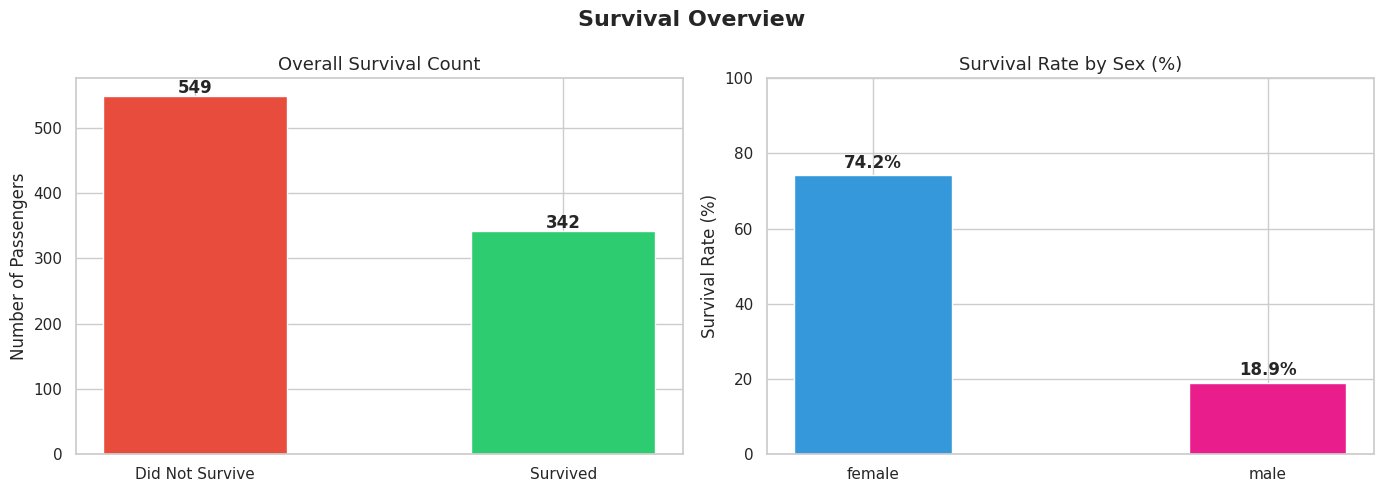

Plot 1 saved


In [ ]:
# PLOT 1 (Seaborn): Survival Distribution & Survival by Sex

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Survival Overview', fontsize=16, fontweight='bold')

# Left: Count plot
counts = pdf['Survived'].map({0: 'Did Not Survive', 1: 'Survived'}).value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Overall Survival Count', fontsize=13)
axes[0].set_ylabel('Number of Passengers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Right: Survival rate by sex
surv_sex = pdf.groupby('Sex')['Survived'].mean() * 100
bar_colors = ['#3498db', '#e91e8c']
axes[1].bar(surv_sex.index, surv_sex.values, color=bar_colors, edgecolor='white', width=0.4)
axes[1].set_title('Survival Rate by Sex (%)', fontsize=13)
axes[1].set_ylabel('Survival Rate (%)')
axes[1].set_ylim(0, 100)
for i, v in enumerate(surv_sex.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_survival_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 1 saved')

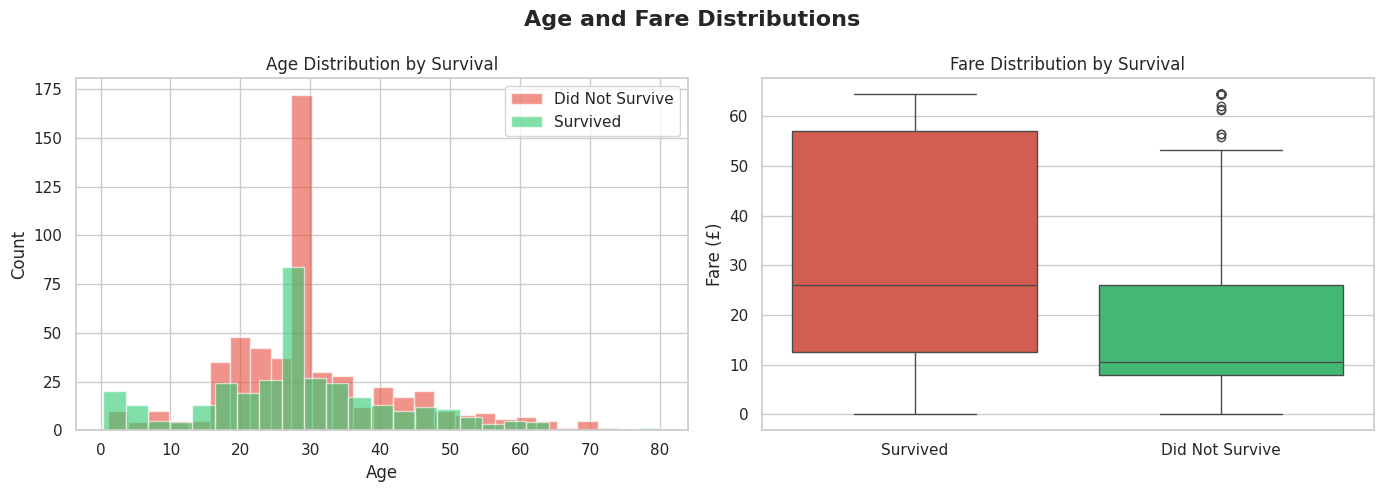

Plot 2 saved


In [ ]:
# PLOT 2 (Seaborn): Age Distribution by Survival Status

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age and Fare Distributions', fontsize=16, fontweight='bold')

# Age KDE
for survived, color, label in [(0, '#e74c3c', 'Did Not Survive'), (1, '#2ecc71', 'Survived')]:
    subset = pdf[pdf['Survived'] == survived]['Age'].dropna()
    axes[0].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0].set_title('Age Distribution by Survival')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Fare boxplot
surv_labels = pdf['Survived'].map({0: 'Did Not Survive', 1: 'Survived'})
pdf_temp = pdf.copy()
pdf_temp['Survived_Label'] = surv_labels
sns.boxplot(data=pdf_temp, x='Survived_Label', y='Fare', ax=axes[1],
            palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Fare Distribution by Survival')
axes[1].set_xlabel('')
axes[1].set_ylabel('Fare (£)')

plt.tight_layout()
plt.savefig('plot2_age_fare.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 2 saved')

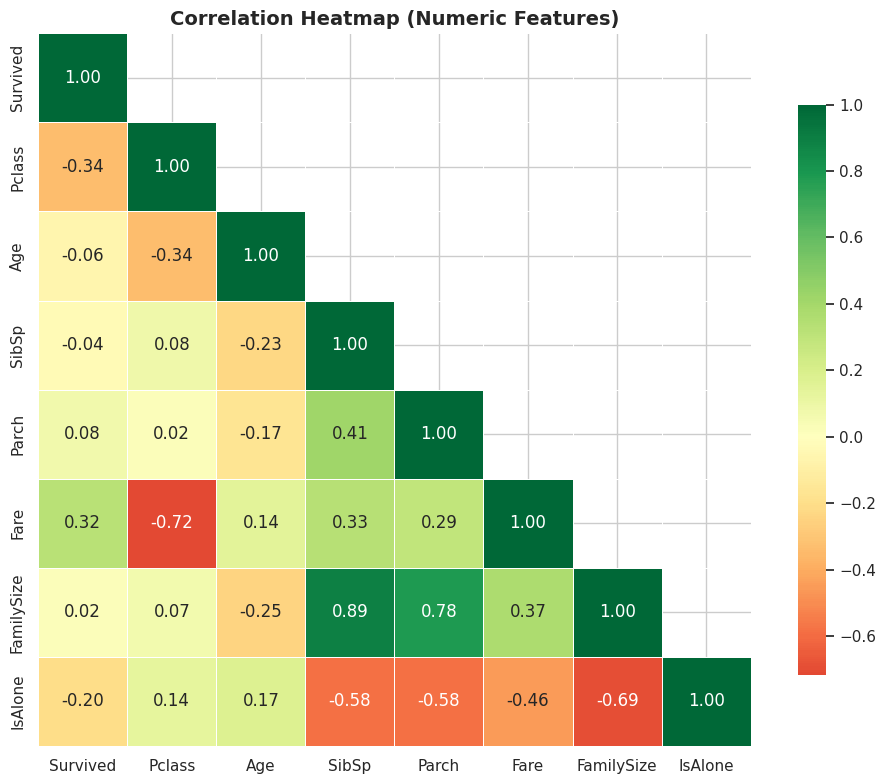

Plot 3 saved


In [ ]:
# PLOT 3 (Seaborn): Correlation Heatmap

num_cols_viz = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
corr_matrix = pdf[num_cols_viz].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
import numpy as np
mask_upper = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, ax=ax,
            mask=mask_upper, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 3 saved')

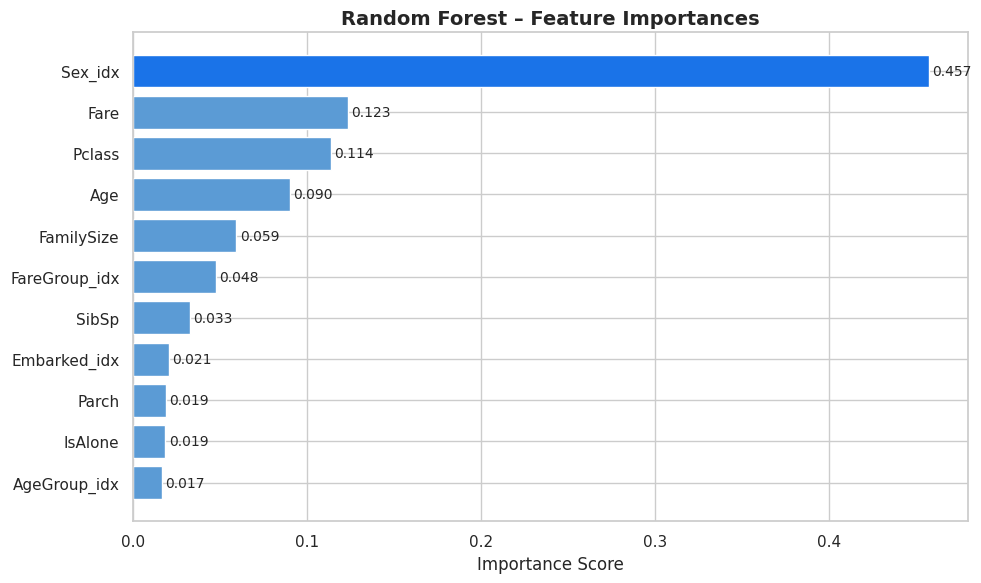

Plot 4 saved


In [ ]:
# PLOT 4 (Matplotlib): Feature Importances

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = ['#1a73e8' if i == 0 else '#5b9bd5' for i in range(len(feat_imp))]
bars = ax.barh(feat_imp['Feature'], feat_imp['Importance'],
               color=colors_fi, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Random Forest – Feature Importances', fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, feat_imp['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot 4 saved')

In [ ]:
# PLOT 5 (Plotly): Survival Rate by Class × Sex (interactive)

surv_group = pdf.groupby(['Pclass', 'Sex'])['Survived'].mean().reset_index()
surv_group['Survived'] = surv_group['Survived'] * 100
surv_group['Pclass'] = surv_group['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

fig = px.bar(surv_group, x='Pclass', y='Survived', color='Sex',
             barmode='group',
             title='Survival Rate by Passenger Class and Sex',
             labels={'Survived': 'Survival Rate (%)', 'Pclass': 'Passenger Class'},
             color_discrete_map={'male': '#3498db', 'female': '#e91e8c'},
             text_auto='.1f')
fig.update_layout(plot_bgcolor='white', yaxis_range=[0, 100])
fig.show()
print('Plot 5 rendered')

Plot 5 rendered


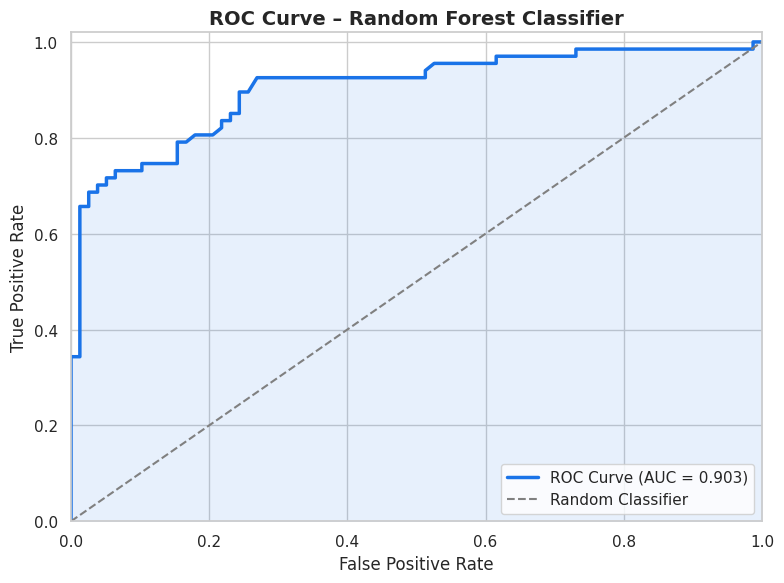

Plot 6 saved | Final AUC: 0.9031


In [ ]:
# PLOT 6 (Matplotlib): ROC Curve

from sklearn.metrics import roc_curve, auc as sklearn_auc

fpr, tpr, _ = roc_curve(pred_pdf['label'], pred_pdf['prob_positive'])
roc_auc = sklearn_auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#1a73e8', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0,1], [0,1], color='gray', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#1a73e8')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve – Random Forest Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plot6_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot 6 saved | Final AUC: {roc_auc:.4f}')

In [ ]:
# FINAL SUMMARY

print('PROJECT FINAL SUMMARY')
print(f'Dataset      : Titanic ({df_loaded.count()} passengers)')
print(f'Algorithm    : Random Forest (100 trees)')
print(f'Accuracy     : {acc*100:.1f}%')
print(f'AUC-ROC      : {auc:.4f}')
print(f'F1-Score     : {f1:.4f}')
print(f'Top Feature  : {feat_imp.iloc[0]["Feature"]:<20}')

# Stop Spark session
spark.stop()
print('\nSparkSession stopped.')

PROJECT FINAL SUMMARY
Dataset      : Titanic (891 passengers)
Algorithm    : Random Forest (100 trees)
Accuracy     : 82.8%
AUC-ROC      : 0.9031
F1-Score     : 0.8261
Top Feature  : Sex_idx             

SparkSession stopped.
